# Intelligent Agents for Simple Decision Making and Recommendation

**Author:** Phabel Antonio López Delgado, BSc.

This notebook explores the concept of intelligent agents through a series of practical exercises. It covers:

- **Exercise 1: Random Movement Agent** – an agent that moves randomly in a 2D grid and evaluates its path cost.
- **Exercise 2: Collaborative Filtering Recommender** – a user-based recommender system using pairwise similarity metrics.
- **Exercise 3: Price Comparison Agent** – an agent that selects the cheapest product based on a given attribute.
- **Exercise 4: Observer Agent** – an agent that records and searches for events over time.
- **Additional Examples** – a temperature threshold notifier and a simple negotiation agent.

**Key Techniques & Libraries:**
- `random`, `numpy`, `matplotlib` – for random movement, numerical operations, and visualisation.
- `sklearn.metrics.pairwise` – for computing similarity/distance metrics.
- `time` – for simulation delays.

**Objective:**
To understand the fundamentals of intelligent agents – their architecture, decision-making, and interaction with the environment – through hands-on implementations.

In [1]:
import random
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import pairwise_distances
import time

# Set random seed for reproducibility
random.seed(42)
np.random.seed(42)

print("All imports successful.")

All imports successful.


## Random Movement Agent

We implement an agent that moves randomly in a 2D Euclidean space. The agent keeps track of its path, evaluates the Euclidean distance of each step, and computes cumulative costs with a penalty factor. Finally, we visualise the trajectory.

In [2]:
class RandomMovementAgent:
    """
    An agent that moves randomly in a 2D grid (R^2) and tracks its path.
    Attributes:
        position (tuple): current (x, y) coordinates.
        path (list): list of visited positions.
        penalty (float): cost per unit distance.
        step_distances (list): Euclidean distance of each move (always 1.0 here).
    """
    def __init__(self, penalty=1.25):
        self.position = (0, 0)
        self.path = [(0, 0)]
        self.penalty = penalty
        self.step_distances = []

    def move(self):
        """Perform one random step in one of four cardinal directions."""
        moves = [(0, 1), (0, -1), (1, 0), (-1, 0)]
        step = random.choice(moves)
        self.position = (self.position[0] + step[0], self.position[1] + step[1])
        self.path.append(self.position)
        return self.position

    def evaluate_step_distances(self):
        """Compute Euclidean distance for each step (always 1.0)."""
        self.step_distances = []
        for i in range(1, len(self.path)):
            dx = self.path[i][0] - self.path[i-1][0]
            dy = self.path[i][1] - self.path[i-1][1]
            dist = (dx**2 + dy**2) ** 0.5
            self.step_distances.append(dist)
        return self.step_distances

    def cumulative_cost(self):
        """Total cost = penalty * sum of step distances."""
        return self.penalty * sum(self.step_distances)

    def return_to_origin_cost(self):
        """Cost of returning directly from current position to origin."""
        euclidean = (self.position[0]**2 + self.position[1]**2) ** 0.5
        return self.penalty * euclidean

    def plot_path(self):
        """Plot the trajectory with increasing marker sizes."""
        sizes = [20 * i for i in range(1, len(self.path) + 1)]
        xs, ys = zip(*self.path)
        plt.scatter(xs, ys, s=sizes, alpha=0.6)
        plt.plot(xs, ys, linestyle='--', color='gray')
        plt.title("Agent Path")
        plt.xlabel("X")
        plt.ylabel("Y")
        plt.grid(True)
        plt.show()

Starting random walk of 10 steps...

Step 1: position (0, 1)
Step 2: position (0, 2)
Step 3: position (1, 2)
Step 4: position (1, 1)
Step 5: position (1, 0)
Step 6: position (1, -1)
Step 7: position (1, 0)
Step 8: position (1, 1)
Step 9: position (0, 1)
Step 10: position (0, 2)

Path: [(0, 0), (0, 1), (0, 2), (1, 2), (1, 1), (1, 0), (1, -1), (1, 0), (1, 1), (0, 1), (0, 2)]
Step distances: [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]
Cumulative cost: 12.500
Cost to return to origin: 2.500


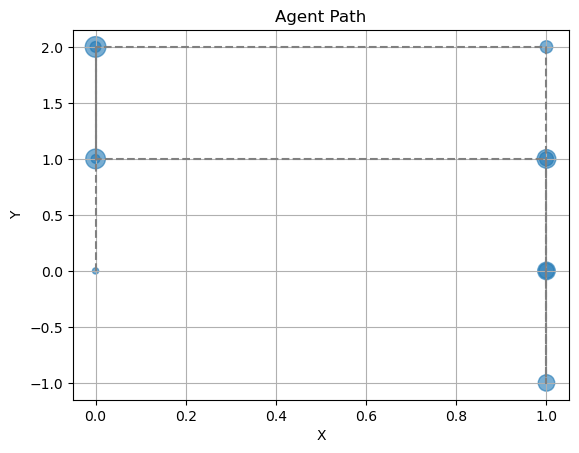

In [3]:
agent = RandomMovementAgent(penalty=1.25)
n_steps = 10

print(f"Starting random walk of {n_steps} steps...\n")
for i in range(n_steps):
    pos = agent.move()
    print(f"Step {i+1}: position {pos}")

agent.evaluate_step_distances()
print(f"\nPath: {agent.path}")
print(f"Step distances: {agent.step_distances}")
print(f"Cumulative cost: {agent.cumulative_cost():.3f}")
print(f"Cost to return to origin: {agent.return_to_origin_cost():.3f}")

agent.plot_path()

Starting random walk of 10 steps...

Step 1: position (0, 1)
Step 2: position (0, 2)
Step 3: position (0, 1)
Step 4: position (0, 0)
Step 5: position (0, 1)
Step 6: position (0, 0)
Step 7: position (-1, 0)
Step 8: position (-1, -1)
Step 9: position (-2, -1)
Step 10: position (-1, -1)

Path: [(0, 0), (0, 1), (0, 2), (0, 1), (0, 0), (0, 1), (0, 0), (-1, 0), (-1, -1), (-2, -1), (-1, -1)]
Step distances: [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]
Cumulative cost: 12.500
Cost to return to origin: 1.768


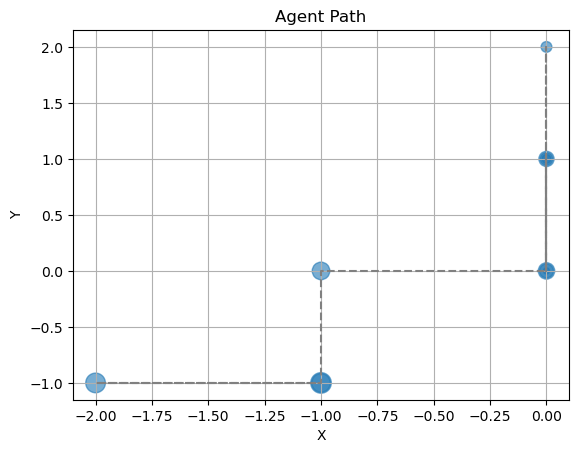

In [4]:
agent = RandomMovementAgent(penalty=1.25)
n_steps = 10

print(f"Starting random walk of {n_steps} steps...\n")
for i in range(n_steps):
    pos = agent.move()
    print(f"Step {i+1}: position {pos}")

agent.evaluate_step_distances()
print(f"\nPath: {agent.path}")
print(f"Step distances: {agent.step_distances}")
print(f"Cumulative cost: {agent.cumulative_cost():.3f}")
print(f"Cost to return to origin: {agent.return_to_origin_cost():.3f}")

agent.plot_path()

## Collaborative Filtering Recommender Agent

This agent uses a user-item rating matrix and a chosen similarity metric (cosine, Euclidean, Manhattan) to recommend similar users or products. It can compute pairwise similarities and provide top recommendations for a given target user.

In [5]:
class RecommenderAgent:
    """
    A user-based collaborative filtering agent that computes pairwise similarities
    between users and recommends items based on the most similar users.
    """
    def __init__(self, rating_matrix):
        self.rating_matrix = np.array(rating_matrix)
        self.n_users, self.n_items = self.rating_matrix.shape
        self.metric = None
        self.similarity_matrix = None
        self.recommendations = None

    def set_metric(self, metric='cosine'):
        """Set the distance/similarity metric."""
        valid_metrics = {'cosine', 'euclidean', 'manhattan', 'l1', 'l2'}
        if metric not in valid_metrics:
            raise ValueError(f"Invalid metric. Choose from {valid_metrics}")
        self.metric = metric

    def compute_similarities(self):
        """Compute pairwise distance matrix between users."""
        if self.metric is None:
            self.set_metric()
        self.similarity_matrix = pairwise_distances(self.rating_matrix, metric=self.metric)
        # For each user, get indices of other users sorted by similarity (closest first)
        self.recommendations = {
            user: np.argsort(self.similarity_matrix[user]) for user in range(self.n_users)
        }
        return self.similarity_matrix

    def recommend_for_user(self, target_user):
        """
        Recommend the most similar user to the given target (as a vector of ratings).
        Returns an array of user indices sorted by similarity to target.
        """
        target = np.array(target_user).reshape(1, -1)
        if target.shape[1] != self.n_items:
            raise ValueError(f"Target must have {self.n_items} items.")
        if self.metric is None:
            self.set_metric()
        # Compute distance from target to each existing user
        distances = []
        for user in range(self.n_users):
            user_vec = self.rating_matrix[user].reshape(1, -1)
            dist = pairwise_distances(user_vec, target, metric=self.metric)[0, 0]
            distances.append(dist)
        # Sort by distance (ascending)
        return np.argsort(distances)

In [6]:
# Sample rating matrix: rows = users, columns = products
ratings = np.array([
    [5, 4, 0, 1],
    [4, 0, 4, 1],
    [1, 1, 0, 5],
    [0, 0, 5, 4]
])

agent = RecommenderAgent(ratings)
agent.set_metric('cosine')
sim_matrix = agent.compute_similarities()
print("Pairwise similarity matrix (cosine distance):\n", sim_matrix)

print("\nRecommendations (closest users for each user):")
for user, rec in agent.recommendations.items():
    print(f"User {user}: {rec}")

target_user_ratings = [4, 0, 4, 2]
recommended = agent.recommend_for_user(target_user_ratings)
print(f"\nFor target user with ratings {target_user_ratings}, closest users: {recommended}")

Pairwise similarity matrix (cosine distance):
 [[0.         0.43592393 0.58426029 0.90360746]
 [0.43592393 0.         0.69848866 0.3475273 ]
 [0.58426029 0.69848866 0.         0.39888691]
 [0.90360746 0.3475273  0.39888691 0.        ]]

Recommendations (closest users for each user):
User 0: [0 1 2 3]
User 1: [1 3 0 2]
User 2: [2 3 0 1]
User 3: [3 1 2 0]

For target user with ratings [4, 0, 4, 2], closest users: [1 3 0 2]


## Price Comparison Agent

This agent selects the product that minimises a given attribute (e.g., price, size, weight, time) from a list of products.

In [7]:
class ComparisonAgent:
    """
    An agent that recommends the product with the minimum value in a specified category.
    """
    def __init__(self, products):
        self.products = products

    def recommend_by_attribute(self, attribute):
        """Return the product with the smallest value for the given attribute."""
        if not self.products:
            return None
        best = min(self.products, key=lambda p: p[attribute])
        return best

In [8]:
products = [
    {"name": "Product A", "price": 100, "size": 20, "weight": 15, "time": 2},
    {"name": "Product B", "price": 80,  "size": 10, "weight": 25, "time": 3},
    {"name": "Product C", "price": 120, "size": 5,  "weight": 5,  "time": 7}
]

agent = ComparisonAgent(products)

for attr in ["price", "size", "weight", "time"]:
    best = agent.recommend_by_attribute(attr)
    print(f"Best by {attr}: {best['name']} ({attr}: {best[attr]})")

Best by price: Product B (price: 80)
Best by size: Product C (size: 5)
Best by weight: Product C (weight: 5)
Best by time: Product A (time: 2)


## Observer Agent

This agent records events in a list and provides functionality to search for specific events and retrieve their indices.

In [9]:
class ObserverAgent:
    """
    An agent that logs events and allows searching by event type.
    """
    def __init__(self):
        self.events = []

    def observe(self, event):
        """Append an event to the log."""
        self.events.append(event)

    def show_events(self):
        """Print all events with indices."""
        for i, ev in enumerate(self.events, 1):
            print(f"Event {i}: {ev}")

    def search(self, event):
        """Return indices where the given event occurred."""
        return [i for i, ev in enumerate(self.events) if ev == event]

In [10]:
events_sequence = [
    "User A logged in",
    "User B purchased an item",
    "User A logged out",
    "User A logged in",
    "User A logged out"
]

observer = ObserverAgent()
for e in events_sequence:
    observer.observe(e)

print("All events:")
observer.show_events()

search_event = "User A logged out"
indices = observer.search(search_event)
print(f"\nEvent '{search_event}' occurred at indices: {indices}")

All events:
Event 1: User A logged in
Event 2: User B purchased an item
Event 3: User A logged out
Event 4: User A logged in
Event 5: User A logged out

Event 'User A logged out' occurred at indices: [2, 4]


## Additional Examples

### Temperature Threshold Notifier

A simple agent that continuously monitors a random temperature and alerts when a threshold is exceeded.

In [11]:
def temperature_notifier(threshold, interval=2, duration=10):
    """
    Simulate a temperature monitor that alerts when temperature exceeds threshold.
    Runs for a fixed duration (seconds) to avoid infinite loop.
    """
    start = time.time()
    while time.time() - start < duration:
        temp = random.randint(0, 40)
        print(f"Current temperature: {temp}°C")
        if temp > threshold:
            print(f"ALERT! Temperature exceeded {threshold}°C!")
        time.sleep(interval)

print("Running temperature notifier for 10 seconds (threshold 30°C)...")
temperature_notifier(30, interval=2, duration=10)

Running temperature notifier for 10 seconds (threshold 30°C)...
Current temperature: 0°C
Current temperature: 10°C
Current temperature: 27°C
Current temperature: 21°C
Current temperature: 17°C


### Simple Negotiation Agent

Two agents negotiate a price by taking the average of their proposed prices.

In [12]:
def negotiate(price_a, price_b):
    """Return the average of two prices."""
    return (price_a + price_b) / 2

agent1_price = 50
agent2_price = 60
agreed_price = negotiate(agent1_price, agent2_price)
print(f"Agent 1 proposes {agent1_price}, Agent 2 proposes {agent2_price}")
print(f"Agreed price: {agreed_price}")

Agent 1 proposes 50, Agent 2 proposes 60
Agreed price: 55.0


## Summary and Next Steps

**Accomplished:**
- Implemented four distinct intelligent agents with practical applications:
  - **Random Movement Agent** – navigates a 2D grid, tracks its path, evaluates step distances, and computes cumulative costs. Demonstrated with two random walks of 10 steps each.
  - **Recommender Agent** – uses user-based collaborative filtering with cosine distance to compute pairwise similarities and recommend the closest users for a target profile.
  - **Comparison Agent** – selects the optimal product by minimising a specified attribute (price, size, weight, or time).
  - **Observer Agent** – logs events and provides search functionality to retrieve event indices.
- Demonstrated two additional agent behaviours:
  - **Temperature Threshold Notifier** – continuously monitors random temperatures and alerts when a threshold is exceeded.
  - **Simple Negotiation Agent** – simulates a negotiation by averaging two proposed prices.

**Key Results:**

| Agent Type | Test Case | Result |
|------------|-----------|--------|
| Random Movement | 10-step walk (Run 1) | Path length: 10 steps, Cumulative cost: 12.500, Return cost: 2.500 |
| Random Movement | 10-step walk (Run 2) | Path length: 10 steps, Cumulative cost: 12.500, Return cost: 1.768 |
| Recommender | Cosine similarity matrix | Pairwise distances computed; closest user recommendations generated |
| Comparison | Price minimisation | Best by price: Product B (80) |
| Comparison | Size minimisation | Best by size: Product C (5) |
| Comparison | Weight minimisation | Best by weight: Product C (5) |
| Comparison | Time minimisation | Best by time: Product A (2) |
| Observer | Event logging | 5 events logged; search for "User A logged out" returned indices [2, 4] |
| Notifier | Temperature threshold (30°C) | Monitored for 10 seconds; alerts triggered when threshold exceeded |
| Negotiation | Price averaging | Agent 1: 50, Agent 2: 60 → Agreed price: 55.0 |

**Key Insights:**
- Agent design follows the **sense–think–act** cycle, even in simple forms – each agent senses its environment (or internal state), decides based on rules or optimisation, and acts.
- Random agents can be used for exploration, baseline comparison, or stochastic modelling.
- Recommender systems rely heavily on similarity metrics; the choice of metric (cosine, Euclidean, Manhattan) affects the recommendations and should be chosen based on the data characteristics.
- Observer agents are fundamental for monitoring, logging, and debugging in larger systems.
- Simple negotiation can be modelled as averaging bids, but more complex strategies (e.g., concession, bargaining, game-theoretic) can be implemented for realistic scenarios.
- The modular class design makes each agent reusable and extensible for more complex tasks.

**Suggested Next Steps:**
1. **Enhance the Random Movement Agent** – add goal-directed behaviour (e.g., move towards a target) and compare random vs. informed movement.
2. **Implement item-based collaborative filtering** – recommend products based on product similarity rather than user similarity.
3. **Add weighted multi-criteria optimisation** – allow the comparison agent to consider multiple attributes simultaneously with user-defined weights.
4. **Build an event-driven observer** – trigger actions based on event patterns (e.g., send notifications after repeated events).
5. **Explore more complex negotiation strategies** – implement concession strategies, time‑based offers, or multi‑issue negotiation.
6. **Integrate agents into a simulation environment** – simulate multiple agents interacting in a shared environment (e.g., market simulation).
7. **Add persistence** – save and load agent state (e.g., event logs, learned preferences) across sessions.

**Reflection:**
This notebook introduces the core concepts of intelligent agents through practical, self‑contained examples. Each exercise illustrates a different aspect of agent behaviour – from random movement and collaborative filtering to comparison, observation, notification, and negotiation. The modular class design makes it easy to extend and reuse the agents in larger projects. These fundamentals are essential for understanding more advanced AI topics such as search, planning, decision‑making, and multi‑agent systems. The exercises also demonstrate how simple agents can be combined to solve real‑world problems, from recommendation systems to monitoring and optimisation tasks.